In [6]:
import pandas as pd
import numpy as np

# 1. Load the original dataset
df = pd.read_csv("AB_NYC_2019.csv")

# -----------------------------------
# 2. Text Normalization 
# -----------------------------------
# Standardizing text to lowercase to ensure consistency and improve grouping
df['name'] = df['name'].str.lower()
df['host_name'] = df['host_name'].str.lower()
df['neighbourhood'] = df['neighbourhood'].str.lower()

# -----------------------------------
# 3. Handling Missing Values and Duplicates
# -----------------------------------
# Removing duplicate rows
df.drop_duplicates(inplace=True)

# Dropping rows where essential information (listing or host name) is missing
df.dropna(subset=['name', 'host_name'], inplace=True)

# Filling missing values in 'reviews_per_month' with 0 as no reviews were recorded
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# -----------------------------------
# 4. Data Cleaning (Logical Filters)
# -----------------------------------
# Keeping realistic prices (between $1 and $1000)
df = df[(df['price'] > 0) & (df['price'] < 1000)]

# Removing listings with unrealistic 'minimum_nights' (more than a year)
df = df[df['minimum_nights'] < 365]

# -----------------------------------
# 5. Outlier Removal using IQR Method
# -----------------------------------
# Calculating the Interquartile Range (IQR) for the price column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering data to keep only values within the non-outlier range
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# -----------------------------------
# 6. Final Formatting and Export
# -----------------------------------
# Dropping columns that are not useful for general data analysis
cols_to_drop = ['id', 'host_id', 'last_review']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Resetting the index to maintain a clean numerical order
df.reset_index(drop=True, inplace=True)

# Save the finalized cleaned dataset
df.to_csv("airbnb_cleaned.csv", index=False)

print("Final dataset is ready!")
print(f"Cleaned Data Shape: {df.shape}")
print(df.head())

Final dataset is ready!
Cleaned Data Shape: (45840, 13)
                                               name    host_name  \
0                clean & quiet apt home by the park         john   
1                             skylit midtown castle     jennifer   
2               the village of harlem....new york !    elisabeth   
3                   cozy entire floor of brownstone  lisaroxanne   
4  entire apt: spacious studio/loft by central park        laura   

  neighbourhood_group neighbourhood  latitude  longitude        room_type  \
0            Brooklyn    kensington  40.64749  -73.97237     Private room   
1           Manhattan       midtown  40.75362  -73.98377  Entire home/apt   
2           Manhattan        harlem  40.80902  -73.94190     Private room   
3            Brooklyn  clinton hill  40.68514  -73.95976  Entire home/apt   
4           Manhattan   east harlem  40.79851  -73.94399  Entire home/apt   

   price  minimum_nights  number_of_reviews  reviews_per_month  \
0    1

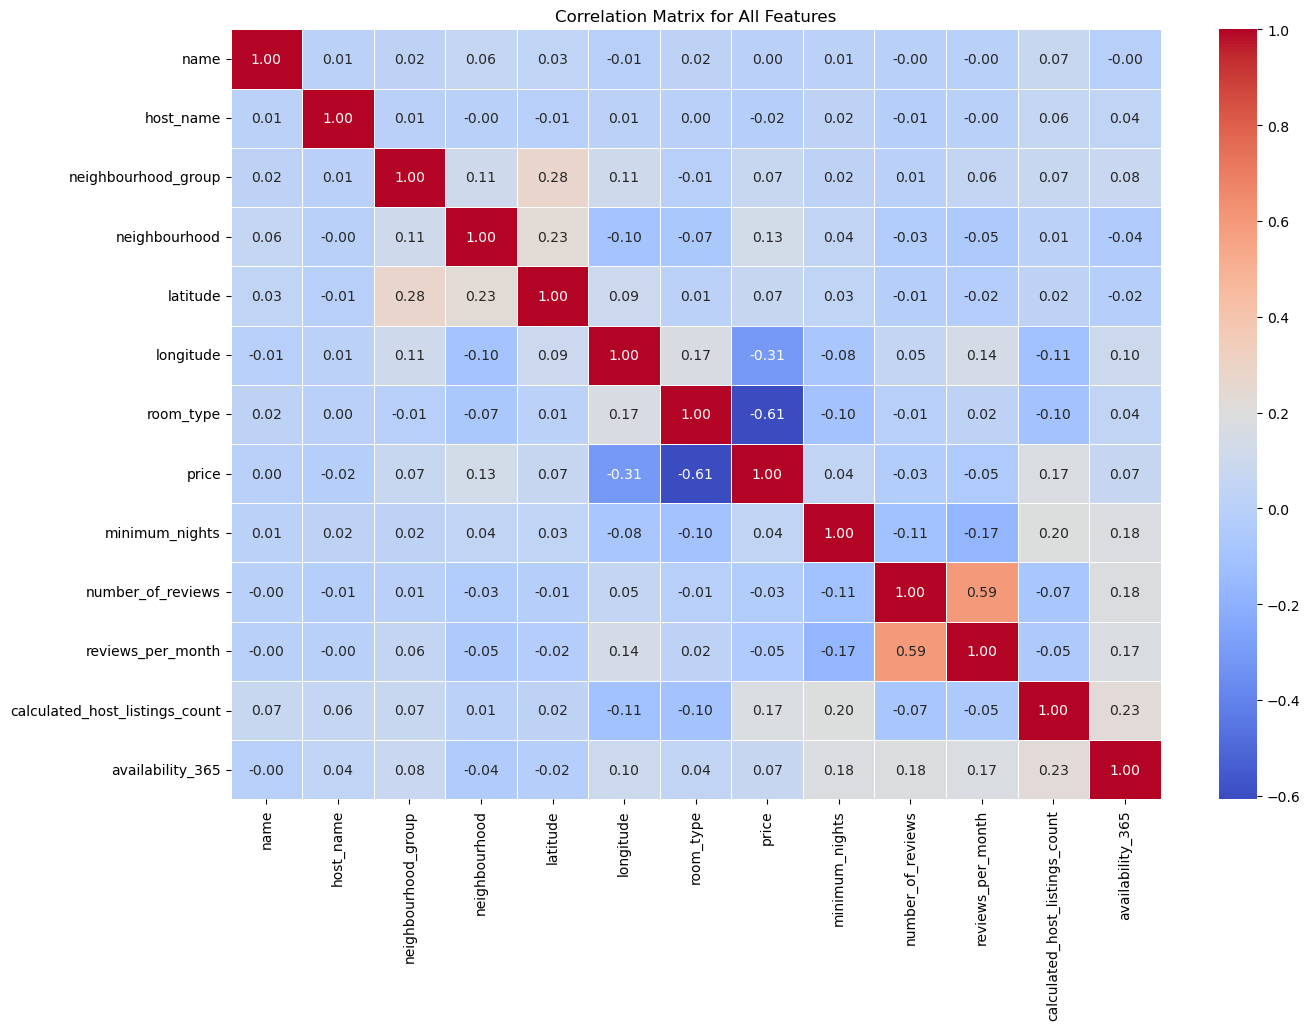

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('airbnb_cleaned.csv')

df_full_corr = df.copy()
for col in df_full_corr.select_dtypes(include=['object']).columns:
    df_full_corr[col] = df_full_corr[col].astype('category').cat.codes

corr_matrix = df_full_corr.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix for All Features')
plt.show()

In [8]:
df = pd.read_csv('airbnb_cleaned.csv')

selected_columns = [
    'price',                          
    'room_type',                      
    'longitude',                    
    'latitude',                   
    'neighbourhood_group',          
    'calculated_host_listings_count', 
    'availability_365'               
]

df_model = df[selected_columns].copy()

df_model['room_type_code'] = df_model['room_type'].astype('category').cat.codes
df_model['neighbourhood_group_code'] = df_model['neighbourhood_group'].astype('category').cat.codes

df_model.to_csv('airbnb_model_data.csv', index=False)

print(df_model.head())

   price        room_type  longitude  latitude neighbourhood_group  \
0    149     Private room  -73.97237  40.64749            Brooklyn   
1    225  Entire home/apt  -73.98377  40.75362           Manhattan   
2    150     Private room  -73.94190  40.80902           Manhattan   
3     89  Entire home/apt  -73.95976  40.68514            Brooklyn   
4     80  Entire home/apt  -73.94399  40.79851           Manhattan   

   calculated_host_listings_count  availability_365  room_type_code  \
0                               6               365               1   
1                               2               355               0   
2                               1               365               1   
3                               1               194               0   
4                               1                 0               0   

   neighbourhood_group_code  
0                         1  
1                         2  
2                         2  
3                         1  
4 